

# Bitcoin News: Time Series Sentiment & Price Prediction
This notebook demonstrates how we can use real-time news data to:
- Extract daily sentiment and topics
- Aggregate into time series features
- Join with Bitcoin prices
- Predict BTC price movement using ML models


In [13]:
!pip install seaborn

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 79.5 MB/s eta 0:00:0000:0100:01


In [10]:
pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


 #####  Load Summarized News CSV

In [2]:
import pandas as pd

# Load saved summary data
df = pd.read_csv("bitcoin_100_articles_summary.csv")
df.head()


,published_date,title,summary,sentiment,source
0,2025-05-10,Bitcoin Price Could Be Gearing Up For Paraboli...,The Bitcoin price has been a joy to watch over...,POSITIVE,Bitcoinist
1,2025-05-10,I fucking love bitcoin!,"The difference of seeking news media, when you...",NEGATIVE,Erickimphotography.com
2,2025-05-10,Is Bitcoin Price Heading To $137K? Market Expe...,Created by industry experts and meticulously r...,POSITIVE,newsBTC
3,2025-05-10,The Vibes From Dubai: What Token2049 Chatter R...,Last weeks Token2049 conference brought togeth...,POSITIVE,Decrypt
4,2025-05-10,"El Salvador stacks 7 Bitcoin in last week, des...",The government of El Salvador continues stacki...,NEGATIVE,Cointelegraph


 ##### Preprocess Dates and Sentiment

In [3]:
df["published_date"] = pd.to_datetime(df["published_date"]).dt.date
sentiment_map = {"POSITIVE": 1, "NEGATIVE": -1, "NEUTRAL": 0}
df["sentiment_score"] = df["sentiment"].map(sentiment_map)


##### Daily Aggregation of Sentiment

In [4]:
daily_sentiment = df.groupby("published_date")["sentiment_score"].mean().reset_index()


 ##### Extract Daily Topics via TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine all summaries per day
daily_text = df.groupby("published_date")["summary"].apply(lambda x: " ".join(x)).reset_index()

# Run TF-IDF on combined daily summaries
vectorizer = TfidfVectorizer(max_features=10, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(daily_text["summary"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Combine date + TF-IDF
daily_features = pd.concat([daily_text["published_date"], tfidf_df], axis=1)


##### Merge Sentiment + Topics

In [8]:
final_features = pd.merge(daily_features, daily_sentiment, on="published_date")
final_features


,published_date,bitcoin,btc,chars,crypto,gt,industry,open,return,tariffs,trump,sentiment_score
0,2025-04-21,0.755842,0.000000,0.654754,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.2
1,2025-04-22,0.817088,0.249219,0.000000,0.222146,0.000000,0.000000,0.000000,0.000000,0.000000,0.470009,-0.2
2,2025-04-23,0.386436,0.294665,0.000000,0.262656,0.000000,0.000000,0.000000,0.000000,0.000000,0.833578,0.2
3,2025-04-24,0.383920,0.000000,0.000000,0.000000,0.000000,0.585494,0.000000,0.000000,0.714005,0.000000,-0.2
4,2025-04-25,0.946818,0.000000,0.000000,0.321771,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.2
5,2025-04-26,0.089223,0.000000,0.309162,0.000000,0.717460,0.000000,0.331871,0.309162,0.331871,0.256617,-0.2
6,2025-04-27,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.6
7,2025-04-28,0.165914,0.000000,0.287448,0.225539,0.667070,0.253025,0.308562,0.287448,0.308562,0.238594,-0.6
8,2025-04-29,0.000000,0.000000,0.000000,0.510799,0.000000,0.286525,0.000000,0.000000,0.000000,0.810548,0.2
9,2025-04-30,0.296262,0.000000,0.000000,0.805465,0.000000,0.000000,0.000000,0.513279,0.000000,0.000000,0.6


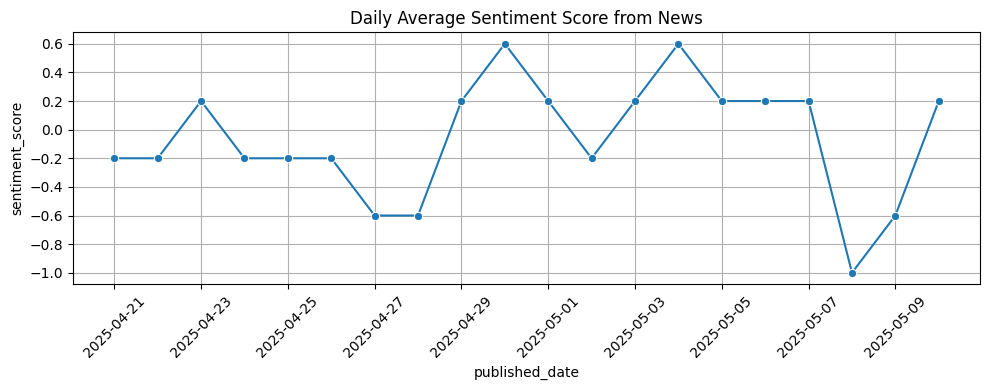

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.lineplot(data=final_features, x="published_date", y="sentiment_score", marker="o")
plt.title("Daily Average Sentiment Score from News")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

##### Fetch Historical Bitcoin Prices



In [15]:
import requests

def get_btc_price_history(days: int = 30) -> pd.DataFrame:
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
    params = {
        "vs_currency": "usd",
        "days": days,
        "interval": "daily"
    }
    r = requests.get(url, params=params).json()
    prices = r["prices"]
    
    df_price = pd.DataFrame(prices, columns=["timestamp", "price"])
    df_price["published_date"] = pd.to_datetime(df_price["timestamp"], unit="ms").dt.date
    df_price = df_price.groupby("published_date").mean().reset_index()
    return df_price[["published_date", "price"]]


In [16]:
df_price = get_btc_price_history(30)
df_price.head()


,published_date,price
0,2025-04-12,83439.288180
1,2025-04-13,85305.097284
2,2025-04-14,83600.820101
3,2025-04-15,84523.452491
4,2025-04-16,83656.492489


##### Merge Sentiment + Price Data

In [17]:
df_merged = pd.merge(final_features, df_price, on="published_date")
df_merged = df_merged.sort_values("published_date")
df_merged.head()


,published_date,bitcoin,btc,chars,crypto,gt,industry,open,return,tariffs,trump,sentiment_score,price
0,2025-04-21,0.755842,0.000000,0.654754,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,-0.2,85073.165449
1,2025-04-22,0.817088,0.249219,0.000000,0.222146,0.0,0.000000,0.0,0.0,0.000000,0.470009,-0.2,87452.046991
2,2025-04-23,0.386436,0.294665,0.000000,0.262656,0.0,0.000000,0.0,0.0,0.000000,0.833578,0.2,93576.165886
3,2025-04-24,0.383920,0.000000,0.000000,0.000000,0.0,0.585494,0.0,0.0,0.714005,0.000000,-0.2,93605.452309
4,2025-04-25,0.946818,0.000000,0.000000,0.321771,0.0,0.000000,0.0,0.0,0.000000,0.000000,-0.2,93872.814229


In [20]:
df_merged

,published_date,bitcoin,btc,chars,crypto,gt,industry,open,return,tariffs,trump,sentiment_score,price,target_price
0,2025-04-21,0.755842,0.000000,0.654754,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.2,85073.165449,87452.046991
1,2025-04-22,0.817088,0.249219,0.000000,0.222146,0.000000,0.000000,0.000000,0.000000,0.000000,0.470009,-0.2,87452.046991,93576.165886
2,2025-04-23,0.386436,0.294665,0.000000,0.262656,0.000000,0.000000,0.000000,0.000000,0.000000,0.833578,0.2,93576.165886,93605.452309
3,2025-04-24,0.383920,0.000000,0.000000,0.000000,0.000000,0.585494,0.000000,0.000000,0.714005,0.000000,-0.2,93605.452309,93872.814229
4,2025-04-25,0.946818,0.000000,0.000000,0.321771,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.2,93872.814229,94773.112006
5,2025-04-26,0.089223,0.000000,0.309162,0.000000,0.717460,0.000000,0.331871,0.309162,0.331871,0.256617,-0.2,94773.112006,94644.066371
6,2025-04-27,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.6,94644.066371,93809.337820
7,2025-04-28,0.165914,0.000000,0.287448,0.225539,0.667070,0.253025,0.308562,0.287448,0.308562,0.238594,-0.6,93809.337820,95030.606455
8,2025-04-29,0.000000,0.000000,0.000000,0.510799,0.000000,0.286525,0.000000,0.000000,0.000000,0.810548,0.2,95030.606455,94256.359463
9,2025-04-30,0.296262,0.000000,0.000000,0.805465,0.000000,0.000000,0.000000,0.513279,0.000000,0.000000,0.6,94256.359463,94235.753310


##### Add Target Column (Next Day Price)

In [18]:
df_merged["target_price"] = df_merged["price"].shift(-1)
df_merged = df_merged.dropna()


In [19]:
import numpy as np

# Shift target column by -1 to predict next day's price
df_merged["target_price"] = df_merged["price"].shift(-1)
df_model = df_merged.dropna()

# Extract features and target
features = df_model.drop(columns=["published_date", "price", "target_price"]).values
target = df_model["target_price"].values

# Normalize features
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
features_scaled = scaler_x.fit_transform(features)

scaler_y = MinMaxScaler()
target_scaled = scaler_y.fit_transform(target.reshape(-1, 1))

# Create sequences for RNN
X = []
y = []

# Use 3-day rolling windows
sequence_length = 3

for i in range(len(features_scaled) - sequence_length):
    X.append(features_scaled[i:i+sequence_length])
    y.append(target_scaled[i + sequence_length])

X, y = np.array(X), np.array(y)

In [20]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, verbose=0)

2025-05-11 07:20:14.174292: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-11 07:20:14.420417: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-11 07:20:15.226287: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-11 07:20:15.229584: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 07:20:17.098465: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [23]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

1/1 [==============================] - 0s 112ms/step


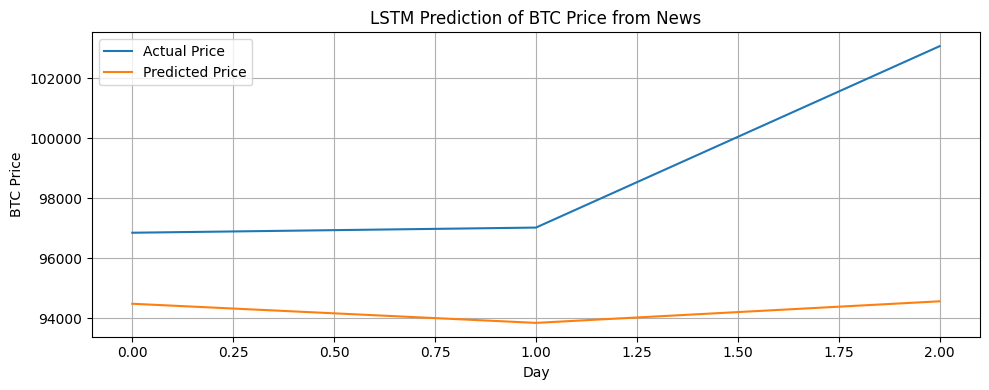

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("LSTM Prediction of BTC Price from News")
plt.xlabel("Day")
plt.ylabel("BTC Price")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()